# Charge Curve Explainer (DC-Only Methodology)

This notebook documents the current charging-duration model used by the bay calculator after the DC-only update.

The model simulates EV bay occupancy per session using:
- A **DC-only** charging profile (`dc_fast`)
- **Battery size** sampling and **battery-to-peak-power correlation**
- A **non-linear SOC power shape** with:
  - a fast low-SOC ramp to plateau
  - a logistic taper as SOC increases
- SOC-step energy integration to convert charge trajectory into duration
- Random session-level jitter and entry/exit buffer time

This aligns with the implementation in `src/BayCalculator.py`.

## 1. Imports

In [1]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np

# Reproducible results for this explainer
random.seed(42)
np.random.seed(42)

print("Libraries loaded.")

Libraries loaded.


## 2. DC Model Parameters

The DC model uses one preset (`dc_fast`) and samples per-session vehicle/charger behavior.

| Parameter | Meaning |
|---|---|
| `battery_kwh_mean`, `battery_kwh_std`, `battery_kwh_min`, `battery_kwh_max` | Distribution and bounds for net battery size |
| `peak_kw_intercept`, `peak_kw_slope`, `peak_kw_std`, `peak_kw_min`, `peak_kw_max` | Battery-size-correlated peak charging power |
| `low_soc_floor`, `low_soc_tau` | Low-SOC ramp shape (non-linear approach to plateau) |
| `taper_mid_soc`, `taper_width` | Logistic taper shape and transition steepness |
| `min_power_fraction` | Minimum power fraction at high SOC |
| `efficiency` | Effective charging efficiency used in duration integration |
| `duration_scale`, `duration_jitter` | Global scaling and stochastic variation before occupancy buffer |

In [2]:
DC_CURVE = {
    "description": "DC fast profile with battery-size-correlated peak and taper",
    "battery_kwh_mean": 72.0,
    "battery_kwh_std": 16.0,
    "battery_kwh_min": 35.0,
    "battery_kwh_max": 130.0,
    "peak_kw_intercept": -8.0,
    "peak_kw_slope": 2.75,
    "peak_kw_std": 24.0,
    "peak_kw_min": 45.0,
    "peak_kw_max": 360.0,
    "low_soc_floor": 0.70,
    "low_soc_tau": 0.040,
    "taper_mid_soc": 0.64,
    "taper_width": 0.11,
    "min_power_fraction": 0.14,
    "efficiency": 0.94,
    "duration_scale": 1.00,
    "duration_jitter": 0.12,
}

print(DC_CURVE["description"])

DC fast profile with battery-size-correlated peak and taper


## 3. SOC Start/Target Distributions (DC Sessions)

Each synthetic session draws an initial and target SOC with DC-oriented ranges.

### Initial SOC

$$
\text{initial\_soc} = \min\left(0.78,\ \text{Beta}(2.0, 4.6)\right)
$$

### Target SOC

$$
\text{target\_soc} \sim \mathcal{U}(0.62, 0.88)
$$

If `target_soc <= initial_soc`, target SOC is nudged up by a random increment in `[0.08, 0.24]` and capped at `0.98`.

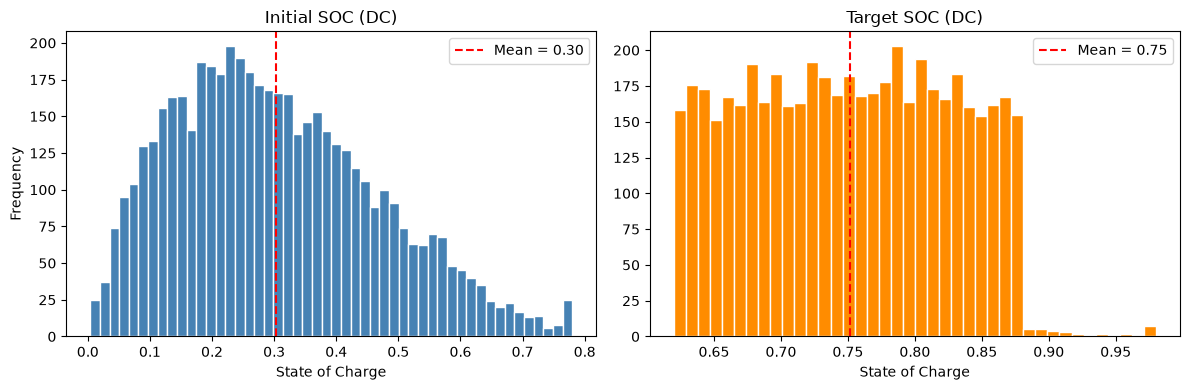

Initial SOC -> mean=0.303, std=0.163
Target SOC  -> mean=0.751, std=0.075


In [3]:
n_samples = 5000

initial_socs = np.minimum(0.78, np.random.beta(2.0, 4.6, n_samples))
target_socs = np.random.uniform(0.62, 0.88, n_samples)

# Apply same target-floor logic as the model
for i in range(n_samples):
    if target_socs[i] <= initial_socs[i]:
        target_socs[i] = min(0.98, initial_socs[i] + np.random.uniform(0.08, 0.24))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(initial_socs, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Initial SOC (DC)")
axes[0].set_xlabel("State of Charge")
axes[0].set_ylabel("Frequency")
axes[0].axvline(initial_socs.mean(), color="red", linestyle="--", label=f"Mean = {initial_socs.mean():.2f}")
axes[0].legend()

axes[1].hist(target_socs, bins=40, color="darkorange", edgecolor="white")
axes[1].set_title("Target SOC (DC)")
axes[1].set_xlabel("State of Charge")
axes[1].axvline(target_socs.mean(), color="red", linestyle="--", label=f"Mean = {target_socs.mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Initial SOC -> mean={initial_socs.mean():.3f}, std={initial_socs.std():.3f}")
print(f"Target SOC  -> mean={target_socs.mean():.3f}, std={target_socs.std():.3f}")

## 4. Non-Linear Power-vs-SOC Shape

The model computes power as a fraction of peak DC power.

Low-SOC behavior is a rapid non-linear approach toward a plateau:

$$
f_{low}(s) = f_0 + (1-f_0)\left(1 - e^{-s/\tau}\right)
$$

High-SOC taper is logistic:

$$
f_{taper}(s) = \frac{1}{1 + e^{(s - s_m)/w}}
$$

Combined power fraction:

$$
f(s) = \text{clip}\left(f_{low}(s) \cdot f_{taper}(s),\ f_{min},\ 1\right)
$$

Then charging power is:

$$
P(s) = P_{peak} \cdot f(s)
$$

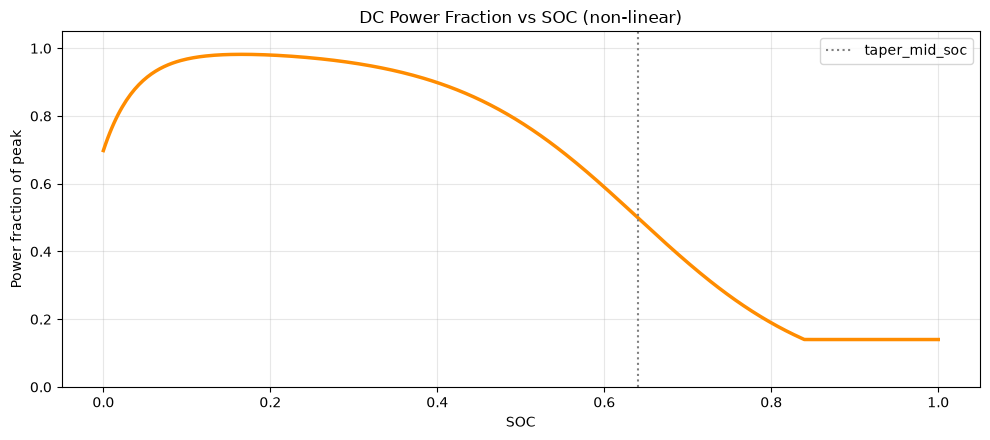

In [4]:
def clip(value, low, high):
    return max(low, min(high, value))

def power_fraction_at_soc(curve, soc):
    low_soc_factor = curve["low_soc_floor"] + (1.0 - curve["low_soc_floor"]) * (
        1.0 - math.exp(-soc / max(1e-4, curve["low_soc_tau"]))
    )
    taper_factor = 1.0 / (1.0 + math.exp((soc - curve["taper_mid_soc"]) / max(1e-4, curve["taper_width"])))
    frac = low_soc_factor * taper_factor
    return clip(frac, curve["min_power_fraction"], 1.0)

soc_grid = np.linspace(0.0, 1.0, 400)
frac_grid = [power_fraction_at_soc(DC_CURVE, s) for s in soc_grid]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(soc_grid, frac_grid, color="darkorange", linewidth=2.5)
ax.axvline(DC_CURVE["taper_mid_soc"], color="gray", linestyle=":", label="taper_mid_soc")
ax.set_title("DC Power Fraction vs SOC (non-linear)")
ax.set_xlabel("SOC")
ax.set_ylabel("Power fraction of peak")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Session Duration via SOC-Step Energy Integration

For each session, the model samples battery size and peak power:

$$
B \sim \mathcal{N}(\mu_B, \sigma_B)\ \text{with clipping},\quad
P_{peak} \sim \mathcal{N}(a + bB, \sigma_P)\ \text{with clipping}
$$

Then it integrates from initial SOC to target SOC in small SOC steps (1%):

$$
t = \sum_{k} \frac{\Delta E_k}{P(s_k)\,\eta}, \quad \Delta E_k = B\,\Delta SOC_k
$$

Finally, it applies duration jitter and adds occupancy buffer minutes.

In [5]:
def draw_soc_pair_dc():
    initial_soc = min(0.78, random.betavariate(2.0, 4.6))
    target_soc = random.uniform(0.62, 0.88)
    if target_soc <= initial_soc:
        target_soc = min(0.98, initial_soc + random.uniform(0.08, 0.24))
    return initial_soc, target_soc

def sample_battery_kwh(curve):
    x = random.gauss(curve["battery_kwh_mean"], curve["battery_kwh_std"])
    return clip(x, curve["battery_kwh_min"], curve["battery_kwh_max"])

def sample_peak_kw(curve, battery_kwh):
    x = random.gauss(
        curve["peak_kw_intercept"] + curve["peak_kw_slope"] * battery_kwh,
        curve["peak_kw_std"],
    )
    return clip(x, curve["peak_kw_min"], curve["peak_kw_max"])

def simulate_soc_duration_minutes(curve, initial_soc, target_soc):
    battery_kwh = sample_battery_kwh(curve)
    peak_kw = sample_peak_kw(curve, battery_kwh)
    efficiency = clip(curve["efficiency"], 0.75, 0.99)

    soc = clip(initial_soc, 0.0, 0.99)
    target = clip(target_soc, soc + 1e-4, 0.995)
    step_soc = 0.01
    total_hours = 0.0

    while soc < target:
        next_soc = min(target, soc + step_soc)
        mean_soc = 0.5 * (soc + next_soc)
        power_kw = max(0.1, peak_kw * power_fraction_at_soc(curve, mean_soc))
        energy_kwh = battery_kwh * (next_soc - soc)
        total_hours += energy_kwh / (power_kw * efficiency)
        soc = next_soc

    scaled_minutes = total_hours * 60.0 * curve["duration_scale"]
    jitter = max(0.65, random.gauss(1.0, curve["duration_jitter"]))
    return max(4.0, scaled_minutes * jitter)

# Quick demonstration of simulated charge-only duration (before occupancy buffer).
random.seed(42)
examples = [simulate_soc_duration_minutes(DC_CURVE, *draw_soc_pair_dc()) for _ in range(5)]
print("Example charge-only minutes:", [round(x, 1) for x in examples])

Example charge-only minutes: [35.8, 18.0, 30.8, 42.9, 21.3]


## 6. Full Session Duration Distribution (DC-Only)

Bay occupancy includes both charging time and entry/exit overhead.

For each session:
1. Simulate charge minutes from SOC integration
2. Add non-negative Gaussian buffer minutes
3. Clamp to a minimum occupancy

$$
t_{final} = \max\left(4,\ t_{charge} + \mathcal{N}^+(4,1)\right)
$$

The histogram below shows the resulting DC session duration distribution.

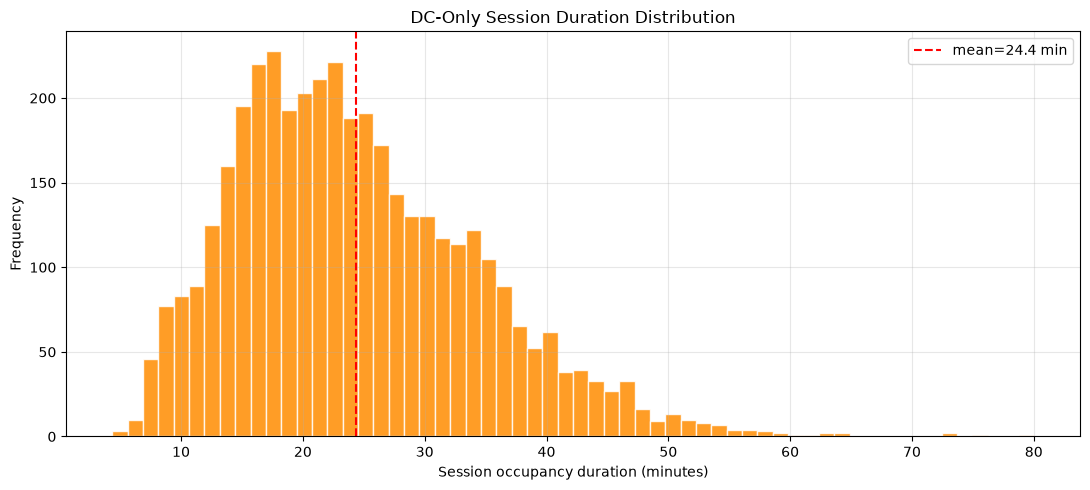

Percentiles: p25=16.9 p50=22.9 p75=30.7 p95=42.6


In [6]:
def sample_session_minutes_dc(curve=DC_CURVE, buffer_mean=4.0, buffer_std=1.0):
    initial_soc, target_soc = draw_soc_pair_dc()
    charge_minutes = simulate_soc_duration_minutes(curve, initial_soc, target_soc)
    buffer_minutes = max(0.0, random.gauss(buffer_mean, buffer_std))
    return max(4.0, charge_minutes + buffer_minutes)

n = 4000
random.seed(42)
durations = [sample_session_minutes_dc() for _ in range(n)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(durations, bins=60, color="darkorange", alpha=0.85, edgecolor="white")
ax.axvline(np.mean(durations), color="red", linestyle="--", label=f"mean={np.mean(durations):.1f} min")
ax.set_xlabel("Session occupancy duration (minutes)")
ax.set_ylabel("Frequency")
ax.set_title("DC-Only Session Duration Distribution")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "Percentiles:",
    f"p25={np.percentile(durations, 25):.1f}",
    f"p50={np.percentile(durations, 50):.1f}",
    f"p75={np.percentile(durations, 75):.1f}",
    f"p95={np.percentile(durations, 95):.1f}",
)

## 7. End-to-End: From Sessions to Bay Count (DC-Only)

`BayCalculator.calc_all_hours` converts hourly session demand into required bays by summing sampled session occupancy time in each hour:

$$
\text{bays\_required}_h = \left\lceil \sum_{i=1}^{N_h} \frac{t_i}{60} \right\rceil
$$

Below is a self-contained commuter-style daily simulation using the DC-only duration model.

Peak demand: 7 bays at 08:00
Utilisation at peak: 88.1%


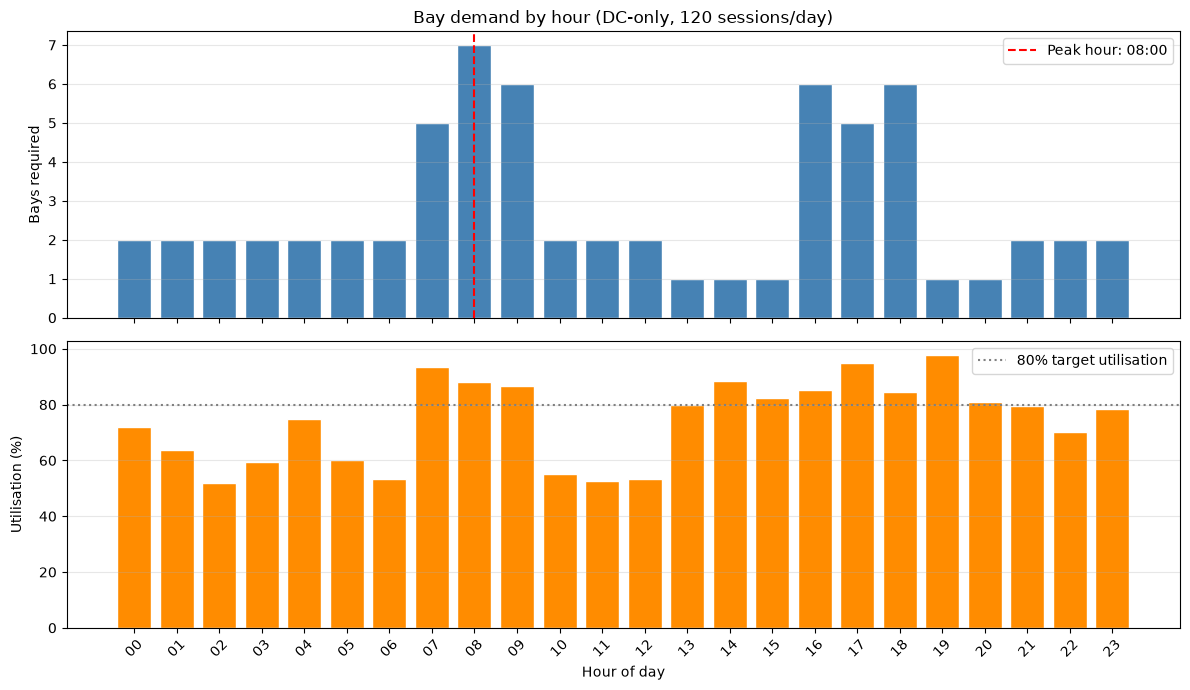

In [7]:
# Commuter double-peak profile
raw_dist = [0.0] * 24
for i in range(7, 10):
    raw_dist[i] = 0.10
for i in range(16, 19):
    raw_dist[i] = 0.10

leftover = 1.0 - sum(raw_dist)
off_peak_hours = sum(1 for v in raw_dist if v == 0.0)
for i in range(24):
    if raw_dist[i] == 0.0:
        raw_dist[i] = leftover / off_peak_hours

hourly_dist = [v / sum(raw_dist) for v in raw_dist]
total_sessions = 120

random.seed(0)
bays_per_hour = []
util_per_hour = []

for prop in hourly_dist:
    session_count = max(0, round(prop * total_sessions))
    bay_hours = sum(sample_session_minutes_dc() / 60.0 for _ in range(session_count))
    bays = math.ceil(bay_hours)
    bays_per_hour.append(bays)
    util_per_hour.append((bay_hours / bays) if bays > 0 else 0.0)

peak_hour = int(np.argmax(bays_per_hour))
print(f"Peak demand: {bays_per_hour[peak_hour]} bays at {peak_hour:02d}:00")
print(f"Utilisation at peak: {util_per_hour[peak_hour]:.1%}")

hours = list(range(24))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.bar(hours, bays_per_hour, color="steelblue", edgecolor="white")
ax1.axvline(peak_hour, color="red", linestyle="--", label=f"Peak hour: {peak_hour:02d}:00")
ax1.set_ylabel("Bays required")
ax1.set_title(f"Bay demand by hour (DC-only, {total_sessions} sessions/day)")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

ax2.bar(hours, [u * 100 for u in util_per_hour], color="darkorange", edgecolor="white")
ax2.axhline(80, color="gray", linestyle=":", label="80% target utilisation")
ax2.set_ylabel("Utilisation (%)")
ax2.set_xlabel("Hour of day")
ax2.set_xticks(hours)
ax2.set_xticklabels([f"{h:02d}" for h in hours], rotation=45)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Parameter Sensitivity (DC-Only)

Instead of comparing AC vs DC, we now test sensitivity to DC-specific assumptions.

This section varies `taper_mid_soc` while holding other parameters fixed, then estimates mean peak bays over several random seeds.

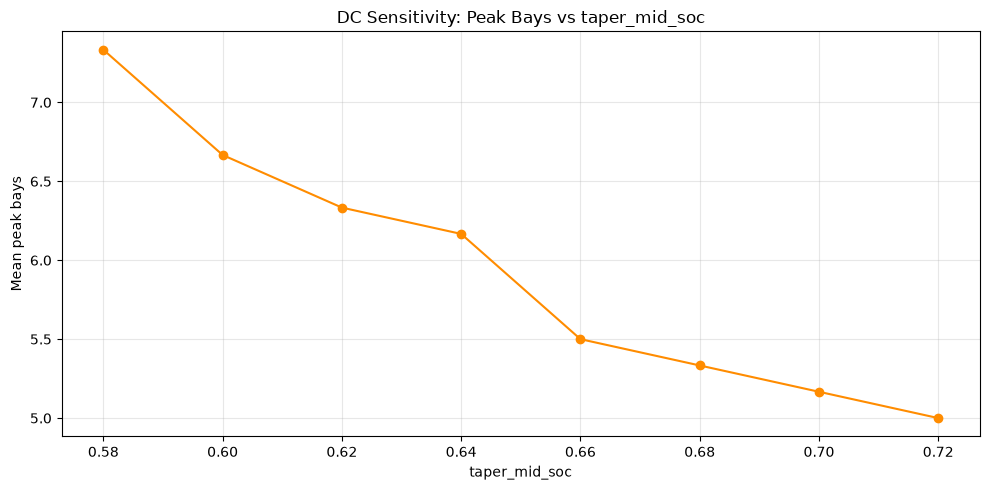

taper_mid_soc=0.580 -> mean_peak_bays=7.33
taper_mid_soc=0.600 -> mean_peak_bays=6.67
taper_mid_soc=0.620 -> mean_peak_bays=6.33
taper_mid_soc=0.640 -> mean_peak_bays=6.17
taper_mid_soc=0.660 -> mean_peak_bays=5.50
taper_mid_soc=0.680 -> mean_peak_bays=5.33
taper_mid_soc=0.700 -> mean_peak_bays=5.17
taper_mid_soc=0.720 -> mean_peak_bays=5.00


In [8]:
taper_mid_values = np.linspace(0.58, 0.72, 8)
n_runs = 6
mean_peak_bays = []

for taper_mid in taper_mid_values:
    peaks = []
    for seed in range(n_runs):
        random.seed(seed)
        curve = dict(DC_CURVE)
        curve["taper_mid_soc"] = float(taper_mid)

        hourly_peaks = []
        for prop in hourly_dist:
            sc = max(0, round(prop * total_sessions))
            bay_hours = 0.0
            for _ in range(sc):
                initial_soc, target_soc = draw_soc_pair_dc()
                charge_minutes = simulate_soc_duration_minutes(curve, initial_soc, target_soc)
                buffer_minutes = max(0.0, random.gauss(4.0, 1.0))
                bay_hours += max(4.0, charge_minutes + buffer_minutes) / 60.0
            hourly_peaks.append(math.ceil(bay_hours))

        peaks.append(max(hourly_peaks))

    mean_peak_bays.append(np.mean(peaks))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(taper_mid_values, mean_peak_bays, "o-", color="darkorange")
ax.set_xlabel("taper_mid_soc")
ax.set_ylabel("Mean peak bays")
ax.set_title("DC Sensitivity: Peak Bays vs taper_mid_soc")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for x, y in zip(taper_mid_values, mean_peak_bays):
    print(f"taper_mid_soc={x:.3f} -> mean_peak_bays={y:.2f}")

## 9. Alignment Check with `BayCalculator`

The final check below uses the same assumptions as the app model and reports a quick Monte Carlo summary for expected session occupancy duration.

n=8,000
mean=24.31 min
std=10.05 min
p05=10.30 min
p50=22.73 min
p95=42.60 min


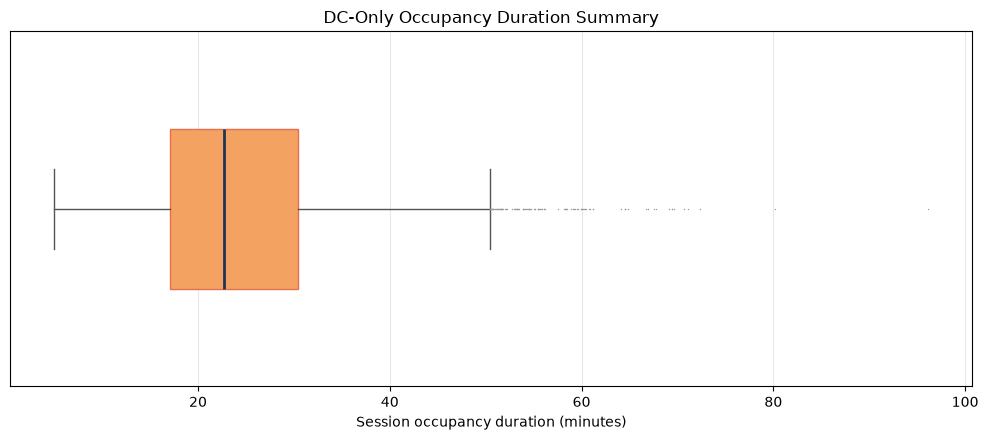

In [10]:
random.seed(123)
n = 8000
samples = np.array([sample_session_minutes_dc() for _ in range(n)])

print(f"n={n:,}")
print(f"mean={samples.mean():.2f} min")
print(f"std={samples.std():.2f} min")
print(f"p05={np.percentile(samples, 5):.2f} min")
print(f"p50={np.percentile(samples, 50):.2f} min")
print(f"p95={np.percentile(samples, 95):.2f} min")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.boxplot(
    samples,
    orientation="horizontal",
    widths=0.45,
    patch_artist=True,
    boxprops=dict(facecolor="#f4a261", color="#e76f51"),
    medianprops=dict(color="#1d3557", linewidth=2),
    whiskerprops=dict(color="#555"),
    capprops=dict(color="#555"),
    flierprops=dict(marker=".", markersize=2, markerfacecolor="#999", markeredgecolor="none"),
)
ax.set_xlabel("Session occupancy duration (minutes)")
ax.set_yticks([])
ax.set_title("DC-Only Occupancy Duration Summary")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Direct Comparison with `src/BayCalculator.py`

This section imports the production `BayCalculator` class directly and compares its sampled DC session durations against an equivalent local mirror implementation in this notebook.

The goal is not exact sample-by-sample equality (random sequences differ), but distribution-level agreement (mean/std/percentiles).

Production BayCalculator (dc_fast): {'mean': 24.038664334857494, 'std': 9.838784663820784, 'p05': 10.127324396211355, 'p50': 22.5478604921093, 'p95': 42.28268878642895}
Notebook mirror implementation:     {'mean': 24.003297728418442, 'std': 9.899840289351392, 'p05': 10.110158357541739, 'p50': 22.5478604921093, 'p95': 42.28268878642895}
Delta (mirror - production): {'mean': -0.0354, 'std': 0.0611, 'p05': -0.0172, 'p50': 0.0, 'p95': 0.0}


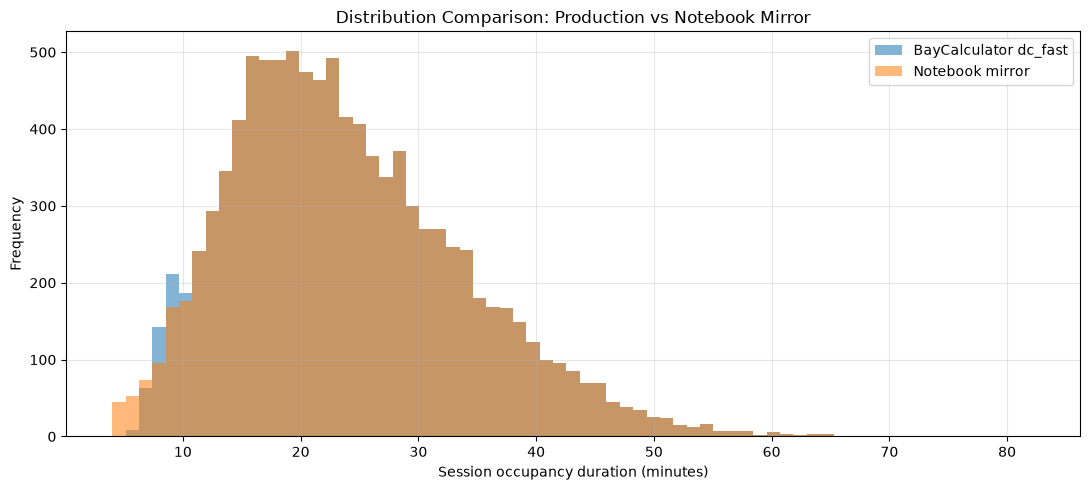

In [1]:
from pathlib import Path
import math
import random
import sys

import matplotlib.pyplot as plt
import numpy as np

# Ensure the workspace root is importable when notebook runs from docs/.
repo_root = Path.cwd()
if (repo_root / "src").exists() is False:
    candidate = repo_root.parent
    if (candidate / "src").exists():
        repo_root = candidate
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.BayCalculator import BayCalculator

def mirror_dc_session_minutes(curve, buffer_mean=4.0, buffer_std=1.0):
    def _clip(v, lo, hi):
        return max(lo, min(hi, v))

    initial_soc = min(0.78, random.betavariate(2.0, 4.6))
    target_soc = random.uniform(0.62, 0.88)
    if target_soc <= initial_soc:
        target_soc = min(0.98, initial_soc + random.uniform(0.08, 0.24))

    battery_kwh = _clip(
        random.gauss(curve["battery_kwh_mean"], curve["battery_kwh_std"]),
        curve["battery_kwh_min"],
        curve["battery_kwh_max"],
    )
    peak_kw = _clip(
        random.gauss(
            curve["peak_kw_intercept"] + curve["peak_kw_slope"] * battery_kwh,
            curve["peak_kw_std"],
        ),
        curve["peak_kw_min"],
        curve["peak_kw_max"],
    )
    efficiency = _clip(curve["efficiency"], 0.75, 0.99)

    soc = _clip(initial_soc, 0.0, 0.99)
    target = _clip(target_soc, soc + 1e-4, 0.995)
    total_hours = 0.0
    step_soc = 0.01

    while soc < target:
        next_soc = min(target, soc + step_soc)
        mean_soc = 0.5 * (soc + next_soc)
        low_soc_factor = curve["low_soc_floor"] + (1.0 - curve["low_soc_floor"]) * (
            1.0 - math.exp(-mean_soc / max(1e-4, curve["low_soc_tau"]))
        )
        taper_factor = 1.0 / (
            1.0 + math.exp((mean_soc - curve["taper_mid_soc"]) / max(1e-4, curve["taper_width"]))
        )
        power_fraction = _clip(
            low_soc_factor * taper_factor,
            curve["min_power_fraction"],
            1.0,
        )
        power_kw = max(0.1, peak_kw * power_fraction)
        energy_kwh = battery_kwh * (next_soc - soc)
        total_hours += energy_kwh / (power_kw * efficiency)
        soc = next_soc

    charge_minutes = total_hours * 60.0 * curve["duration_scale"]
    charge_minutes *= max(0.65, random.gauss(1.0, curve["duration_jitter"]))

    buffer_minutes = max(0.0, random.gauss(buffer_mean, buffer_std))
    return max(4.0, charge_minutes + buffer_minutes)

# Instantiate production calculator (DC-only mode).
prod_calc = BayCalculator(avg_service_time=35.0, safety_buffer=0.15, charge_curve_id="dc_fast")
prod_curve = BayCalculator.CURVE_PRESETS["dc_fast"]

n = 10000
random.seed(2026)
prod_samples = np.array([prod_calc._sample_curve_duration_minutes("dc_fast") for _ in range(n)])

random.seed(2026)
mirror_samples = np.array([mirror_dc_session_minutes(prod_curve) for _ in range(n)])

def describe(x):
    return {
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "p05": float(np.percentile(x, 5)),
        "p50": float(np.percentile(x, 50)),
        "p95": float(np.percentile(x, 95)),
    }

prod_stats = describe(prod_samples)
mirror_stats = describe(mirror_samples)

print("Production BayCalculator (dc_fast):", prod_stats)
print("Notebook mirror implementation:    ", mirror_stats)

deltas = {k: mirror_stats[k] - prod_stats[k] for k in prod_stats}
print("Delta (mirror - production):", {k: round(v, 4) for k, v in deltas.items()})

fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(
    min(prod_samples.min(), mirror_samples.min()),
    max(prod_samples.max(), mirror_samples.max()),
    70,
    endpoint=True,
)
ax.hist(prod_samples, bins=bins, alpha=0.55, label="BayCalculator dc_fast", color="#1f77b4")
ax.hist(mirror_samples, bins=bins, alpha=0.55, label="Notebook mirror", color="#ff7f0e")
ax.set_title("Distribution Comparison: Production vs Notebook Mirror")
ax.set_xlabel("Session occupancy duration (minutes)")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()